In [18]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os
import warnings
from collections import Counter
from transformers import pipeline
import torch
import seaborn as sns

warnings.filterwarnings("ignore")


ANALYTICS_DIR = "../data/analytics_layer/"
MODEL_DIR = "../models/biobert_ner/checkpoint-3939"
OUTPUT_DIR = "../outputs/"
os.makedirs(OUTPUT_DIR, exist_ok = True)

# to make plot styling consistent across charts
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11
})

# # load records
# with open(os.path.join(PROCESSED_DIR, "data.json")) as f:
#     records = json.load(f)

# df= pd.DataFrame(records)
# print(f"Loaded {len(records)} records")
# print(df.columns.tolist())
# print(df.head(2))

In [ ]:
def aggregate_entities(raw_predictions):
    """
    Custom aggregation that correctly merges subword pieces.
    Rule: 
      - B-ADR starts a new entity
      - I-ADR or any ## token continues the current entity
      - New B-ADR after ## tokens = continuation, not new entity
    """
    entities = []
    current_entity = None
    
    for pred in raw_predictions:
        word  = pred['word']
        label = pred['entity']
        score = pred['score']
        start = pred['start']
        end   = pred['end']
        
        is_subword = word.startswith('##')
        
        if is_subword and current_entity is not None:
            # Always merge subwords into current entity
            current_entity['word'] += word.replace('##', '')
            current_entity['end']   = end
            # Keep the max score
            current_entity['score'] = max(current_entity['score'], score)
            
        elif label == 'B-ADR' and not is_subword:
            # Save previous entity if exists
            if current_entity:
                entities.append(current_entity)
            # Start new entity
            current_entity = {
                'word':  word,
                'score': score,
                'start': start,
                'end':   end
            }
            
        elif label == 'I-ADR' and current_entity is not None:
            # Continue current entity
            current_entity['word'] += ' ' + word
            current_entity['end']   = end
            current_entity['score'] = max(current_entity['score'], score)
            
        else:
            # O label — save current entity and reset
            if current_entity:
                entities.append(current_entity)
            current_entity = None
    
    # Don't forget the last entity
    if current_entity:
        entities.append(current_entity)
    
    return entities

In [ ]:
# Use aggregation_strategy=None to get raw predictions
ner_pipeline = pipeline(
    "ner",
    model=MODEL_DIR,
    aggregation_strategy=None,   # raw tokens — we handle aggregation ourselves
    device=0 if torch.cuda.is_available() else -1
)

def extract_adrs(review):
    try:
        raw_preds = ner_pipeline(review[:512])
        # raw_preds is a list of lists when input is a list
        if isinstance(raw_preds[0], list):
            raw_preds = raw_preds[0]
        
        entities  = aggregate_entities(raw_preds)
        
        return [
            e['word'].lower().strip()
            for e in entities
            if e['score'] > 0.85 and len(e['word'].strip()) > 1
        ]
    except Exception as ex:
        print(f"Error: {ex}")
        return []

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Running BioBERT predictions on all records...
This will take ~5 minutes on CPU, ~1 min on GPU


In [19]:
df= pd.read_csv("../data/analytics_layer/data.csv")
df

,drug,condition,review,rating,has_adr,prediction_adr,adr_count,has_pred_adr
0,Jolessa,Birth Control,"""It took 2 months for my body to adjust to the...",7,False,[],0,False
1,Implanon,Birth Control,"""I have had Implanon for about two months now....",8,False,[],0,False
2,Metformin,Polycystic Ovary Syndrome,"""I have only been on Metformin 5 days and I al...",8,True,"['gastrointestinal', 'discomfort', 'food cravi...",4,True
3,Bupropion,Depression,"""I was recently put on Wellbutrin by the Colle...",10,False,[],0,False
4,Lorazepam,Anxiety,"""Can be sedating, but gets the job done""",10,False,[],0,False
...,...,...,...,...,...,...,...,...
29995,Skelaxin,Muscle Spasm,"""I've been taking Skelaxin for my back & neck ...",10,True,"['ache', 'pain', 'pain', 'pain']",4,True
29996,Benlysta,Systemic Lupus Erythematosus,"""Dx with SLE at age 40, after years of searchi...",5,True,"['stiffness', 'migraine']",2,True
29997,Viibryd,Depression,"""I am fighting constant itching on arms. I can...",9,False,[],0,False
29998,Diclofenac,Ankylosing Spondylitis,"""Absolutely changed my life. I got progressive...",10,True,[],0,False


In [17]:
df['review'][2]

'"I have only been on Metformin 5 days and I already see the difference in my symptoms. I have more energy and already lost 1.5lbs. Before, it took me a year to lose 10lbs. I have mild gastrointestinal discomfort but well worth it. It seems to help with food cravings. I used to drink 5 cups of coffee in the morning and I am down to only one without any caffeine withdrawal symptoms. I also don\'t crave sugar or high carb foods. I have a healthy snack in between meals to prevent blood sugar drops such as an apple, berries, or carrots. I would recommend this to anyone suffering from PCOS."'

In [20]:
# Count reviews per drug and ADR rate
drug_stats = df.groupby("drug").agg(
    total_reviews= ('review','count'),
    adr_reviews = ('has_pred_adr', 'sum'),
    avg_rating = ('rating', 'mean'),
    avg_adr_count = ('adr_count', 'mean')
).reset_index()
drug_stats['adr_rate'] = drug_stats['adr_reviews']/drug_stats['total_reviews']
# Keep only drugs with enough reviews for statistical reliability
drug_stats = drug_stats[drug_stats['total_reviews'] >= 50].sort_values(
    'adr_rate', ascending=False
)

print(f"Drugs with 50+ reviews: {len(drug_stats)}")
print(drug_stats.head(10).to_string(index=False))

Drugs with 50+ reviews: 141
                       drug  total_reviews  adr_reviews  avg_rating  avg_adr_count  adr_rate
                Minocycline             52           48    6.711538       2.442308  0.923077
                  Buspirone             90           83    6.533333       2.133333  0.922222
                Sumatriptan             58           53    7.551724       2.689655  0.913793
  Amoxicillin / clavulanate             57           52    5.403509       2.912281  0.912281
              Hydromorphone             53           48    8.113208       2.377358  0.905660
                Milnacipran             50           45    7.180000       2.200000  0.900000
                   Accutane             60           54    8.383333       2.383333  0.900000
Acetaminophen / hydrocodone             93           83    7.827957       2.182796  0.892473
                Tioconazole            136          121    4.522059       2.220588  0.889706
             Desvenlafaxine            117

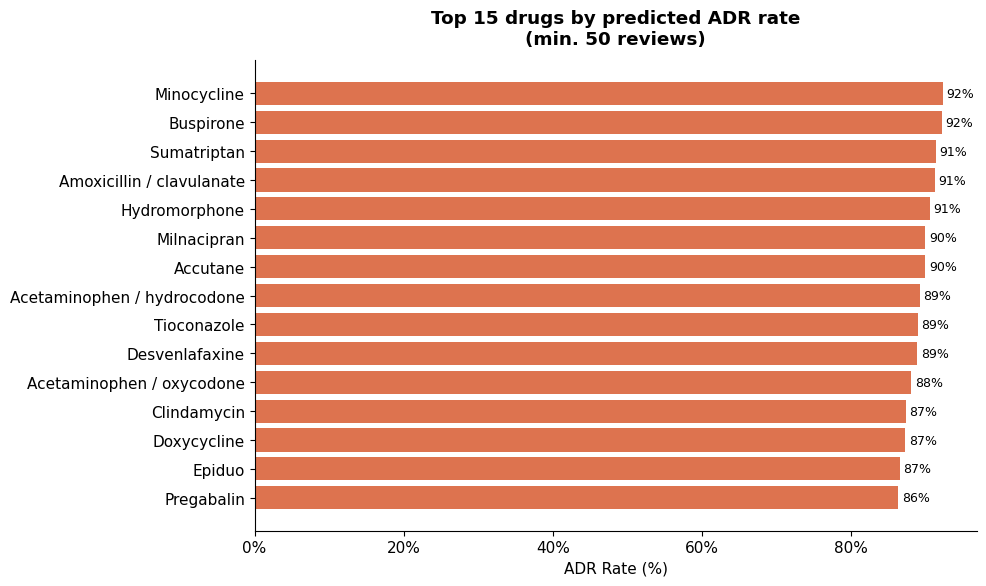

Saved drug_adr_rate.png


In [21]:
top_drugs = drug_stats.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_drugs['drug'][::-1],
    top_drugs['adr_rate'][::-1] * 100,
    color='#D85A30',
    alpha=0.85
)

ax.set_xlabel('ADR Rate (%)')
ax.set_title('Top 15 drugs by predicted ADR rate\n(min. 50 reviews)', 
             fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Add value labels on bars
for bar, val in zip(bars, top_drugs['adr_rate'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "drug_adr_rate.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved drug_adr_rate.png")

Sentiment VS ADR Correlation

Average rating by ADR
adr_bucket     mean      std  count
    No ADR 7.222403 3.263610   9240
     1 ADR 6.961553 3.280102   8011
     2 ADR 6.838666 3.299305   5907
    3+ ADR 6.751938 3.276405   6837


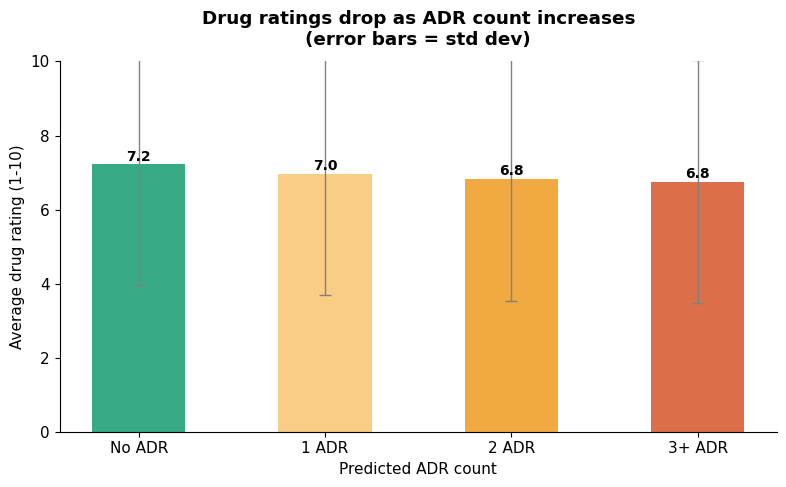

Saved rating_vs_adr.png


In [22]:
df['adr_bucket'] = pd.cut(
    df["adr_count"],
    bins=[-1, 0, 1, 2, 10],
    labels= ["No ADR", "1 ADR", "2 ADR", "3+ ADR"]
)

rating_by_adr = df.groupby('adr_bucket')['rating'].agg(['mean', 'std', 'count']).reset_index()
rating_by_adr

print("Average rating by ADR")
print(rating_by_adr.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1D9E75', '#FAC775', '#EF9F27', '#D85A30']

bars = ax.bar(
    rating_by_adr['adr_bucket'],
    rating_by_adr['mean'],
    color=colors,
    alpha=0.88,
    width=0.5
)

# Error bars showing standard deviation
ax.errorbar(
    rating_by_adr['adr_bucket'],
    rating_by_adr['mean'],
    yerr=rating_by_adr['std'],
    fmt='none', color='gray', capsize=4, linewidth=1
)

ax.set_ylim(0, 10)
ax.set_ylabel('Average drug rating (1-10)')
ax.set_xlabel('Predicted ADR count')
ax.set_title('Drug ratings drop as ADR count increases\n(error bars = std dev)',
             fontweight='bold', pad=12)

# Add mean labels on bars
for bar, val in zip(bars, rating_by_adr['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rating_vs_adr.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved rating_vs_adr.png")

In [23]:
# Flatten all predicted ADR terms
all_adrs= [adr for adrs in df["prediction_adr"] for adr in adrs]
adr_count = Counter(all_adrs)

In [30]:
# Flatten all predicted ADR terms
all_adrs = [adrs for adrs in df['prediction_adr']]
adr_counts = Counter(all_adrs)
print(adr_count)

Counter({"'": 93086, 'i': 39989, 'a': 39717, 'e': 36198, 'n': 35967, ' ': 30738, 's': 30685, '[': 30000, ']': 30000, ',': 25871, 't': 22021, 'r': 19344, 'c': 18700, 'o': 18127, 'p': 13492, 'd': 12757, 'h': 10143, 'g': 9559, 'y': 8501, 'u': 8310, 'l': 8234, 'm': 8139, 'f': 4783, 'b': 3544, 'x': 3535, 'w': 2432, 'k': 1915, 'v': 1446, 'z': 1215, 'j': 161, '.': 61, 'q': 36, '(': 21, '-': 10, ')': 7, '/': 6, ';': 2, ':': 1, '&': 1, '!': 1, '3': 1, '"': 1, '2': 1, '4': 1})


In [38]:
df['prediction_adr']

0                                                       []
1                                                       []
2        ['gastrointestinal', 'discomfort', 'food cravi...
3                                                       []
4                                                       []
                               ...                        
29995                     ['ache', 'pain', 'pain', 'pain']
29996                            ['stiffness', 'migraine']
29997                                                   []
29998                                                   []
29999     ['anxiety', 'dizziness', 'fatigue', 'gastroest']
Name: prediction_adr, Length: 30000, dtype: object

In [42]:
import ast

df['prediction_adr']= df['prediction_adr'].apply(lambda x : ast.literal_eval(x) if isinstance(x, str) else x)
# Verify
print(type(df['prediction_adr'].iloc[2]))

<class 'list'>


Top 20 predicted ADR terms:
     adr_term  count
         pain   4001
      anxiety   3048
   depression   2579
     headache   1767
         acne   1718
       nausea   1639
        migra   1161
      noticed   1036
      painful    988
    infection    929
     insomnia    653
  mood swings    644
    headaches    573
    pregnancy    517
      surgery    508
      fatigue    503
panic attacks    468
 constipation    467
    dizziness    462
      burning    427


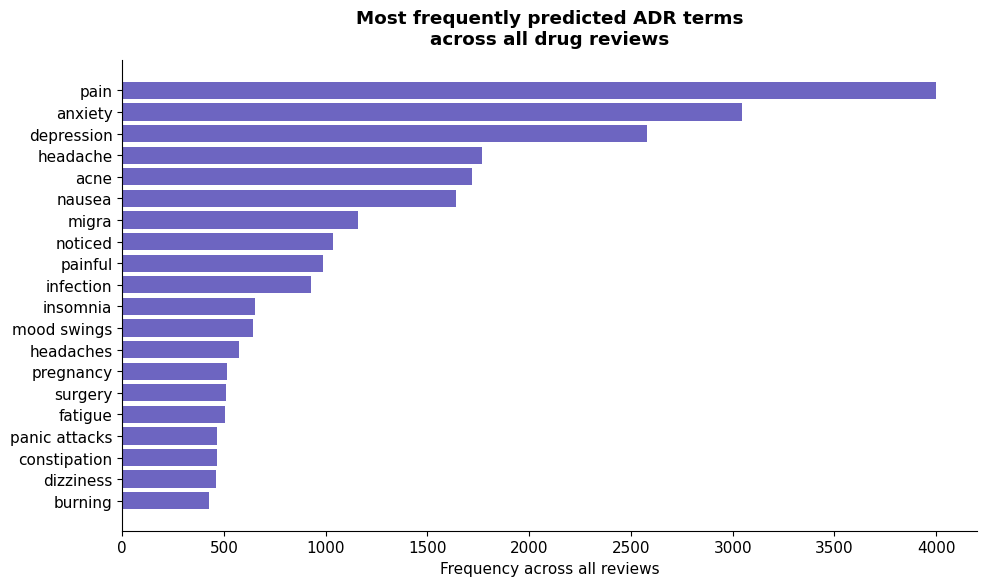

Saved top_adr_terms.png


In [43]:
# Flatten all predicted ADR terms
all_adrs = [adr for adrs in df['prediction_adr'] for adr in adrs]
adr_counts = Counter(all_adrs)

# Take top 20
top_adrs = pd.DataFrame(adr_counts.most_common(20), 
                         columns=['adr_term', 'count'])

print("Top 20 predicted ADR terms:")
print(top_adrs.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_adrs['adr_term'][::-1],
    top_adrs['count'][::-1],
    color='#534AB7',
    alpha=0.85
)
ax.set_xlabel('Frequency across all reviews')
ax.set_title('Most frequently predicted ADR terms\nacross all drug reviews',
             fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_adr_terms.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved top_adr_terms.png")

Top conditions by ADR rate:
                 condition  total_reviews  adr_rate  avg_rating
       Migraine Prevention            269  0.936803    7.215613
                    Asthma             31  0.935484    6.161290
                  Headache            101  0.930693    8.554455
                  Migraine            322  0.916149    7.844720
   Inflammatory Conditions             44  0.909091    8.045455
               Gout, Acute             31  0.903226    9.064516
             Endometriosis            114  0.894737    6.157895
     Peripheral Neuropathy             40  0.875000    6.725000
                      Pain           1141  0.873795    7.376862
                     Cough            156  0.871795    5.647436
                      Acne           1002  0.869261    7.403194
Constipation, Drug Induced             38  0.868421    5.000000


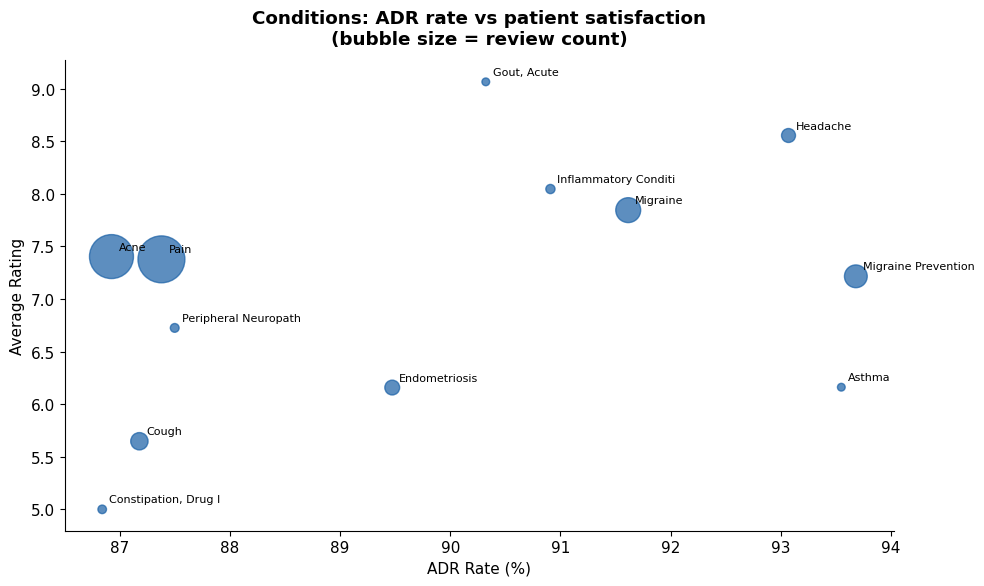

Saved condition_scatter.png


In [45]:
# ADR rate by medical condition
condition_stats = df.groupby('condition').agg(
    total_reviews = ('review', 'count'),
    adr_reviews   = ('has_pred_adr', 'sum'),
    avg_rating    = ('rating', 'mean')
).reset_index()

condition_stats['adr_rate'] = (
    condition_stats['adr_reviews'] / condition_stats['total_reviews']
)

# Keep conditions with enough data
condition_stats = condition_stats[
    condition_stats['total_reviews'] >= 30
].sort_values('adr_rate', ascending=False).head(12)

print("Top conditions by ADR rate:")
print(condition_stats[['condition','total_reviews','adr_rate','avg_rating']]
      .to_string(index=False))

# Plot — scatter: ADR rate vs avg rating, sized by review count
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    condition_stats['adr_rate'] * 100,
    condition_stats['avg_rating'],
    s=condition_stats['total_reviews'],   # bubble size = review count
    alpha=0.7,
    color='#185FA5'
)

# Label each bubble
for _, row in condition_stats.iterrows():
    ax.annotate(
        row['condition'][:20],            # truncate long names
        (row['adr_rate'] * 100, row['avg_rating']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.set_xlabel('ADR Rate (%)')
ax.set_ylabel('Average Rating')
ax.set_title('Conditions: ADR rate vs patient satisfaction\n(bubble size = review count)',
             fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "condition_scatter.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved condition_scatter.png")

In [47]:
# One clean summary table combining everything
master_df = df[[
    'drug', 'condition', 'rating', 
    'has_pred_adr', 'adr_count', 'prediction_adr'
]].copy()

master_df['predicted_adrs_str'] = master_df['prediction_adr'].apply(
    lambda x: ', '.join(x) if x else 'none'
)

master_df.drop(columns=['prediction_adr']).to_csv(
    os.path.join(OUTPUT_DIR, "analytics_master.csv"), index=False
)

print(f"Saved analytics_master.csv — {len(master_df):,} rows")
print("\nFinal summary:")
print(f"  Total reviews analyzed:     {len(df):,}")
print(f"  Reviews with ADR detected:  {df['has_pred_adr'].sum():,} ({df['has_pred_adr'].mean():.1%})")
print(f"  Unique drugs covered:        {df['drug'].nunique():,}")
print(f"  Unique conditions covered:   {df['condition'].nunique():,}")
print(f"  Most common ADR term:        {adr_counts.most_common(1)[0][0]}")

Saved analytics_master.csv — 30,000 rows

Final summary:
  Total reviews analyzed:     30,000
  Reviews with ADR detected:  20,760 (69.2%)
  Unique drugs covered:        2,179
  Unique conditions covered:   622
  Most common ADR term:        pain


In [49]:
print(adr_counts.most_common(1)[0])

('pain', 4001)
